# Predict river streamflow

In this project you will use a neural network to estimate the river steamflow based on gridded meteorological data.

You might want to choose this project if you:
- Want to learn about machine learning for gridded/map-like data
- Want to try out both the multi-layer perceptron (MLP) and the convolutional neural network (CNN) 

![alt text](src/map_catchment.png "Optional Title")

# Problem presentation

We want to predict the streamflow in some rivers around Bergen. We have two different rivers to work with: **Svartavatn**, between Dale and Voss, and **Haukåselva** in Åsane. 

> You can choose between the two catchments or try to do both.


To predict the streamflow in these rivers, we will use gridded data in and around the water catchment. All precipitation that falls within the catchment ends up in the river.
The two catchments are displayed on the following maps as the white shapes with red contours. Bergen is shown as a star for context.

The available data are temperature (minimum `tmin`, mean `tmean` and maximum `tmax`), precipitation `pr` and snow depth `snow_depth`. 

Data comes from MET Norway downloaded through SeKlima (https://seklima.met.no/).




# Load python modules

In [6]:
# Magic formulae so that changes in the .py files are loaded in here
%load_ext autoreload
%autoreload 2
###
    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
from tqdm.notebook import tqdm
import copy

import pandas as pd
import xarray as xr

import torch.nn as nn
import torch.optim as optim
import random
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import sklearn


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# STEP 1 PREPROCESSING DATA
The first step of the machine learning pipeline is to load the data from a file. Here, our data is stored in the two files `data/Data_Svartavatn_1991-2024.nc` and `data/Data_Haukaaselva_2007-2024.nc`. We use the `xarray` library to load the data.

> The data are loaded here for Haukaaselva, but you can change the file here.
>
> **Note that the network definitions depend on the size of the inputs, so be careful with this, you will need to change some numbers!**

In [7]:
ds = xr.open_dataset('data/Data_Haukaaselva_2007-2024.nc')
# ds = xr.open_dataset('data/Data_Svartavatn_1991-2024.nc')
ds

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 6426, Y: 5, X: 5)
Coordinates:
  * time        (time) datetime64[ns] 51kB 2007-03-23 2007-03-24 ... 2024-11-30
  * Y           (Y) float64 40B 6.746e+06 6.746e+06 ... 6.744e+06 6.742e+06
  * X           (X) float64 40B -3.05e+04 -2.95e+04 ... -2.75e+04 -2.65e+04
    lat         (Y, X) float32 100B ...
    lon         (Y, X) float32 100B ...
Data variables:
    tmean       (time, Y, X) float32 643kB ...
    tmin        (time, Y, X) float32 643kB ...
    tmax        (time, Y, X) float32 643kB ...
    pr          (time, Y, X) float32 643kB ...
    snow_depth  (time, Y, X) float32 643kB ...
    streamflow  (time) float64 51kB ...
Attributes: (12/14)
    Conventions:                     CF-1.7
    institution:                     Norwegian Meteorological Institute, MET ...
    creator_url:                     met.no
    geospatial_lat_min:              57.8
    geospatial_lat_max:              72.1
    geospatial_lon_min:              -1.3
    ...                              ...
    source:                          MET Norway
    comment:                         Our open data are licensed under Norwegi...
    title:                           seNorge_2018
    summary:                         seNorge_2018 is an observational gridded...
    version:                         23.09
    DODS_EXTRA.Unlimited_Dimension:  time

Our dataset contains daily values from 2020 to 2025.

Once the data is loaded, we need to turn the datasets into an ML friendly array. To do this, we choose the variables necessary for the analysis and then we transform them into numpy arrays.

In [50]:
X = ds[['tmean','tmin','tmax','pr','snow_depth']] # X is the array containing the data we use to predict the result.
X = X.to_array('var_name')
X = X.transpose('time', 'var_name', ...) # We rearange the data so that the number of samples is the first dimension
X = X.fillna(0).values 
y = ds['streamflow'].values.reshape(-1,1) # y is the array representing the values we want to predict.

## Create train, validation and test datasets from `X` and `y`.

In [71]:
X_train, X_valtest, y_train, y_valtest = sklearn.model_selection.train_test_split(X,y, train_size=0.7)
X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(X_valtest,y_valtest, train_size=0.7)

## Data preprocessing
As a default for the project, the data is not tranformed into a friendly format for the neural network. You can change this by applying some sklearn transform to both X and y.


In [ ]:
#### FOR X, PLEASE CHOOSE ONE PREPROCESSING STYLE: PIXEL WISE SCALING OR PER VARIABLE SCALING

#------- PER VARIABLE SCALING -------#

# Scaler applied for all pixels per variable at a time

all_transforms_x = dict(tmean=sklearn.preprocessing.PowerTransformer(), #tmean
                       tmin=sklearn.preprocessing.PowerTransformer(), #tmin
                       tmax=sklearn.preprocessing.PowerTransformer(), #tmax
                       pr=sklearn.preprocessing.PowerTransformer(), #pr
                       snow_depth=sklearn.preprocessing.PowerTransformer()  #snow_depth
                   )

all_transforms_x['tmean'].fit(X_train[:,0,:].reshape(-1,1)) #Data are flattened to compute the scaler for each variable across all pixels at once
all_transforms_x['tmin'].fit(X_train[:,1,:].reshape(-1,1))
all_transforms_x['tmax'].fit(X_train[:,2,:].reshape(-1,1))
all_transforms_x['pr'].fit(X_train[:,3,:].reshape(-1,1))
all_transforms_x['snow_depth'].fit(X_train[:,4,:].reshape(-1,1))     


tmean_transformed_train = all_transforms_x['tmean'].transform(X_train[:,0,:].reshape(-1,1)).reshape(X_train.shape[0],ds.X.size, ds.Y.size) # We apply the variable specific transform to each variable and reshape the data back to the original shape
tmin_transformed_train = all_transforms_x['tmin'].transform(X_train[:,1,:].reshape(-1,1)).reshape(X_train.shape[0],ds.X.size, ds.Y.size)
tmax_transformed_train = all_transforms_x['tmax'].transform(X_train[:,2,:].reshape(-1,1)).reshape(X_train.shape[0],ds.X.size, ds.Y.size)
pr_transformed_train = all_transforms_x['pr'].transform(X_train[:,3,:].reshape(-1,1)).reshape(X_train.shape[0],ds.X.size, ds.Y.size)
snow_depth_transformed_train = all_transforms_x['snow_depth'].transform(X_train[:,4,:].reshape(-1,1)).reshape(X_train.shape[0],ds.X.size, ds.Y.size)

tmean_transformed_val = all_transforms_x['tmean'].transform(X_val[:,0,:].reshape(-1,1)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)
tmin_transformed_val = all_transforms_x['tmin'].transform(X_val[:,1,:].reshape(-1,1)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)
tmax_transformed_val = all_transforms_x['tmax'].transform(X_val[:,2,:].reshape(-1,1)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)
pr_transformed_val = all_transforms_x['pr'].transform(X_val[:,3,:].reshape(-1,1)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)
snow_depth_transformed_val = all_transforms_x['snow_depth'].transform(X_val[:,4,:].reshape(-1,1)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)

tmean_transformed_test = all_transforms_x['tmean'].transform(X_test[:,0,:].reshape(-1,1)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)
tmin_transformed_test = all_transforms_x['tmin'].transform(X_test[:,1,:].reshape(-1,1)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)
tmax_transformed_test = all_transforms_x['tmax'].transform(X_test[:,2,:].reshape(-1,1)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)
pr_transformed_test = all_transforms_x['pr'].transform(X_test[:,3,:].reshape(-1,1)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)
snow_depth_transformed_test = all_transforms_x['snow_depth'].transform(X_test[:,4,:].reshape(-1,1)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)


X_train = np.stack([tmean_transformed_train, tmin_transformed_train, tmax_transformed_train, pr_transformed_train, snow_depth_transformed_train], axis=1)
X_val = np.stack([tmean_transformed_val, tmin_transformed_val, tmax_transformed_val, pr_transformed_val, snow_depth_transformed_val], axis=1)
X_test = np.stack([tmean_transformed_test, tmin_transformed_test, tmax_transformed_test, pr_transformed_test, snow_depth_transformed_test], axis=1)


#------- PIXEL-WISE SCALING -------#
# Scaler applied for pixels individually
# Commented out by default, but can be used if you want to apply a scaler to each pixel separately.


# all_transforms_x = dict(tmean=sklearn.preprocessing.PowerTransformer(), #tmean
#                        tmin=sklearn.preprocessing.PowerTransformer(), #tmin
#                        tmax=sklearn.preprocessing.PowerTransformer(), #tmax
#                        pr=sklearn.preprocessing.PowerTransformer(), #pr
#                        snow_depth=sklearn.preprocessing.PowerTransformer()  #snow_depth
#                    )

# all_transforms_x['tmean'].fit(X_train[:,0,:].reshape(-1,ds.X.size*ds.Y.size)) #Data are flattened to compute the scaler for each pixel separately
# all_transforms_x['tmin'].fit(X_train[:,1,:].reshape(-1,ds.X.size*ds.Y.size))
# all_transforms_x['tmax'].fit(X_train[:,2,:].reshape(-1,ds.X.size*ds.Y.size))
# all_transforms_x['pr'].fit(X_train[:,3,:].reshape(-1,ds.X.size*ds.Y.size))
# all_transforms_x['snow_depth'].fit(X_train[:,4,:].reshape(-1,ds.X.size*ds.Y.size))     


# tmean_transformed_train = all_transforms_x['tmean'].transform(X_train[:,0,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_train.shape[0],ds.X.size, ds.Y.size) # We apply the variable specific transform to each variable and reshape the data back to the original shape
# tmin_transformed_train = all_transforms_x['tmin'].transform(X_train[:,1,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_train.shape[0],ds.X.size, ds.Y.size)
# tmax_transformed_train = all_transforms_x['tmax'].transform(X_train[:,2,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_train.shape[0],ds.X.size, ds.Y.size)
# pr_transformed_train = all_transforms_x['pr'].transform(X_train[:,3,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_train.shape[0],ds.X.size, ds.Y.size)
# snow_depth_transformed_train = all_transforms_x['snow_depth'].transform(X_train[:,4,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_train.shape[0],ds.X.size, ds.Y.size)

# tmean_transformed_val = all_transforms_x['tmean'].transform(X_val[:,0,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)
# tmin_transformed_val = all_transforms_x['tmin'].transform(X_val[:,1,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)
# tmax_transformed_val = all_transforms_x['tmax'].transform(X_val[:,2,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)
# pr_transformed_val = all_transforms_x['pr'].transform(X_val[:,3,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)
# snow_depth_transformed_val = all_transforms_x['snow_depth'].transform(X_val[:,4,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_val.shape[0],ds.X.size, ds.Y.size)

# tmean_transformed_test = all_transforms_x['tmean'].transform(X_test[:,0,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)
# tmin_transformed_test = all_transforms_x['tmin'].transform(X_test[:,1,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)
# tmax_transformed_test = all_transforms_x['tmax'].transform(X_test[:,2,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)
# pr_transformed_test = all_transforms_x['pr'].transform(X_test[:,3,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)
# snow_depth_transformed_test = all_transforms_x['snow_depth'].transform(X_test[:,4,:].reshape(-1,ds.X.size*ds.Y.size)).reshape(X_test.shape[0],ds.X.size, ds.Y.size)


# X_train = np.stack([tmean_transformed_train, tmin_transformed_train, tmax_transformed_train, pr_transformed_train, snow_depth_transformed_train], axis=1)
# X_val = np.stack([tmean_transformed_val, tmin_transformed_val, tmax_transformed_val, pr_transformed_val, snow_depth_transformed_val], axis=1)
# X_test = np.stack([tmean_transformed_test, tmin_transformed_test, tmax_transformed_test, pr_transformed_test, snow_depth_transformed_test], axis=1)

#------- Y SCALING -------#

transform_y = sklearn.preprocessing.FunctionTransformer() # Does nothing for now

y_train = transform_y.transform(y_train)
y_val = transform_y.transform(y_val)
y_test = transform_y.transform(y_test)

> **_CAREFUL:_**  **Pytorch does not work with numpy arrays**.
> 
> `X` and `y` datasets must be converted to tensor, which is a kind of array with additional properties.

In [74]:
X_train = torch.tensor(X_train, dtype=torch.float)
X_val = torch.tensor(X_val, dtype=torch.float)
X_test = torch.tensor(X_test, dtype=torch.float)

y_train = torch.tensor(y_train, dtype=torch.float)
y_val = torch.tensor(y_val, dtype=torch.float)
y_test = torch.tensor(y_test, dtype=torch.float)

> In addition, we will want to use a GPU, which is a specialized computing unit which allows for faster training. We will talk about it later in the session.
>
> To use the GPU, all data and models must **be** on the GPU. We send data around by using data.to(device).
> 
> We use a device called `cuda`, which corresponds to GPU built by the NVIDIA brand.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

X_train = X_train.to(device)
X_val = X_val.to(device)
X_test = X_test.to(device)

y_train = y_train.to(device)
y_val = y_val.to(device)
y_test = y_test.to(device)

# STEP 2: Define ML model and fit it to the data.


The model we will use in in the `src/model_definition.py` source file. This is where you can change the model.

> For this project, there are two possibilities: either a **MultiLayer Perceptron** or a **Convolutionnal Neural Network**.

In [83]:
from src.define_model import MultiLayerPerceptron3layers, ConvolutionalNeuralNetwork

In [85]:
n_features = 5*5*5 #number of variables x height of image x width of image
n_predictions = 1
model = ConvolutionalNeuralNetwork(input_height=5)
# model = MultiLayerPerceptron3layers(number_input_features=n_features, number_of_predictions=1)

model = model.to(device)

model

ConvolutionalNeuralNetwork(
  (conv_layer1): Conv2d(5, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_layer2): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool_layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layer1): Linear(in_features=20, out_features=16, bias=True)
  (linear_layer2): Linear(in_features=16, out_features=16, bias=True)
  (linear_layer3): Linear(in_features=16, out_features=1, bias=True)
)

## Define hyperparameters for training

In [86]:

# training hyperparameters
n_epochs = 200  # number of epochs to run
batch_size = 256  # size of each batch
learning_rate = 0.0001  # learning rate
index_where_batches_start = torch.arange(0, len(X_train), batch_size)

loss_fn = nn.MSELoss()  # mean square error
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train network
We load training functions from the `src/train_and_evaluate.py` file.

In [87]:
from src.train_and_evaluate import training_one_batch, evaluation_one_epoch

In [88]:
# We keep the weights and biases of the best model
best_loss_value = np.inf   # initialise to infinity
best_weights = None
loss_history = []

# training loop
for epoch in tqdm(range(n_epochs)):
    model.train()
    for start in index_where_batches_start:
    # Select the batch of data
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        training_one_batch(model, X_batch, y_batch, optimizer, loss_fn)
    model.eval()
    best_loss_value, best_weights = evaluation_one_epoch(model, X_val, y_val, 
                                                         loss_fn, loss_history, 
                                                         best_loss_value, best_weights)

# restore model weights to the best model
model.load_state_dict(best_weights)
model = model.eval()


  0%|          | 0/200 [00:00<?, ?it/s]

###  Plot training history: verify that the loss function goes down

MSE: 0.06
RMSE: 0.24


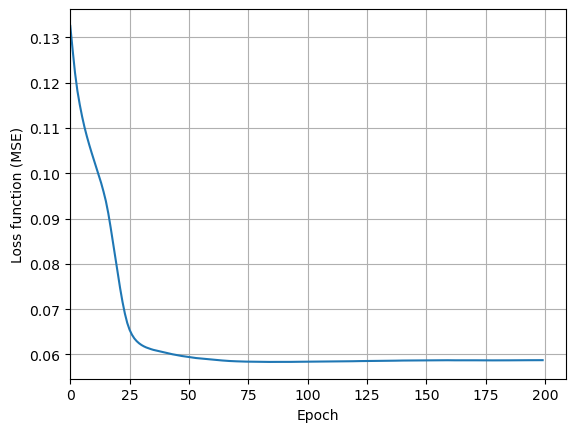

In [89]:
with torch.no_grad():
    best_pred = model(X_val).detach().cpu()


fix, ax = plt.subplots()
# ax.set_ylim(0,None)
print("MSE: %.2f" % best_loss_value)
print("RMSE: %.2f" % np.sqrt(best_loss_value))
ax.plot(loss_history)
ax.set_ylabel('Loss function (MSE)')
ax.set_xlabel('Epoch')
ax.set_xlim(0,None)
ax.grid()
plt.show()

# STEP 3: Make predictions and evaluate the model skill
Once the model is **trained** with the data, we can use it to make predictions.

## Step 3.1: Predict `y_val` from `X_val`
We predict the values of `y` from `X` based on the relation learned by the model. For neural networks with pytorch, there is no `model.predict` method. We only use `model(X)`

In [90]:
y_val_predictions = model(X_val)

## Step 3.2: Plot the results and evaluate the model.
To visually evaluate the model, we plot the predicted `y` values against the true `y` values.


> This part is a bit confusing: pytorch tensors can not be used directly for plots.
>
> Remember how we moved the data to the GPU in the first place? We have to move it back to the "normal" computer unit, the cpu.
> This is done by doing `data.to('cpu')`.
>
> Tensors alse have additional properties that can only be stored on GPU and that differentiate them from normal numpy arrays. We also have to remove them before moving data back to the cpu by doing `data.detach()`.
>
> Overall, we need to write `data_cpu = data.detach().to('cpu')`
>
> Note that we also have to put the y_val back to the 'cpu'.

In [91]:
y_val_predictions_cpu = y_val_predictions.detach().to('cpu')
y_val_cpu = y_val.detach().to('cpu')

We also transform back the `y` values in the original data distribution

In [92]:
y_val_predictions_cpu = transform_y.inverse_transform(y_val_predictions_cpu)
y_val_cpu = transform_y.inverse_transform(y_val_cpu)

### Plot the predictions against the true data for the validation

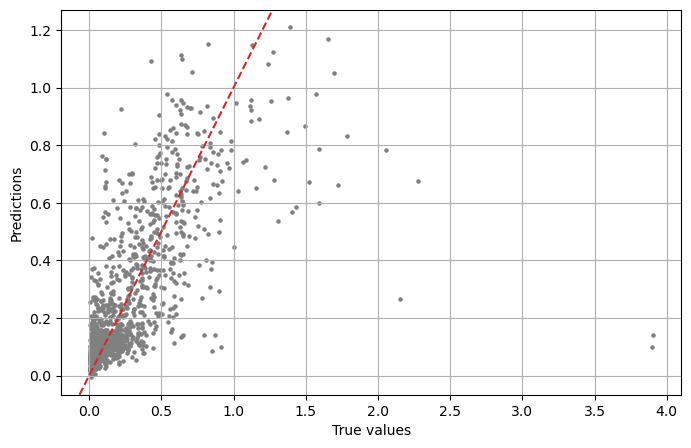

In [93]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(y_val_cpu,y_val_predictions_cpu, s=5, color='.5')
ax.axline((y_val_cpu.mean(), y_val_cpu.mean()), slope=1, ls='--', color='tab:red')
ax.set_ylabel('Predictions')
ax.set_xlabel('True values')
ax.grid()

## We can evaluate the model with scores
### For the full dataset and for predicted variables separately

Note that the R2 score can in fact be negative if the prediction is worse than just saying the average value.

In [94]:
rmse = sklearn.metrics.root_mean_squared_error(y_val_cpu, y_val_predictions_cpu)
r2_score = sklearn.metrics.r2_score(y_val_cpu, y_val_predictions_cpu)

print(f'R2 score: {r2_score}')
print(f'rmse: {rmse}')

R2 score: 0.44915449619293213
rmse: 0.24156177043914795


## Now you're ready to start your projects! 

Now that you've seen the model in action, have a look at how the model is defined in 
`src/define_model.py`, and how it is trained and evaluated in `src/train_and_evaluate.py`.

Here are some things you can experiment with during the projects:
- The choice of optimiser
- The batch size
- The learning rate
- The preprocessing applied to the data
- The network definition

You can also change the catchment you want to apply the project to.